In [ ]:
# Install dependencies
!pip install datasets -q

# Load Amazon reviews dataset from Hugging Face (no account needed)
from datasets import load_dataset
import pandas as pd

dataset = load_dataset("amazon_polarity", split="train[:10000]")
df = pd.DataFrame(dataset)

# Preview
print(df.shape)
print(df.head())
print(df["label"].value_counts())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

amazon_polarity/train-00000-of-00004.par(…):   0%|          | 0.00/260M [00:00<?, ?B/s]

amazon_polarity/train-00001-of-00004.par(…):   0%|          | 0.00/258M [00:00<?, ?B/s]

amazon_polarity/train-00002-of-00004.par(…):   0%|          | 0.00/255M [00:00<?, ?B/s]

amazon_polarity/train-00003-of-00004.par(…):   0%|          | 0.00/254M [00:00<?, ?B/s]

amazon_polarity/test-00000-of-00001.parq(…):   0%|          | 0.00/117M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3600000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/400000 [00:00<?, ? examples/s]

(10000, 3)
   label                                              title  \
0      1                     Stuning even for the non-gamer   
1      1              The best soundtrack ever to anything.   
2      1                                           Amazing!   
3      1                               Excellent Soundtrack   
4      1  Remember, Pull Your Jaw Off The Floor After He...   

                                             content  
0  This sound track was beautiful! It paints the ...  
1  I'm reading a lot of reviews saying that this ...  
2  This soundtrack is my favorite music of all ti...  
3  I truly like this soundtrack and I enjoy video...  
4  If you've played the game, you know how divine...  
label
0    5097
1    4903
Name: count, dtype: int64


In [ ]:
!pip install datasets -q
print("install done")

install done


In [ ]:
from datasets import load_dataset
print("import done")

import done


In [ ]:
dataset = load_dataset("amazon_polarity", split="train[:10000]")
print("load done")
print(type(dataset))

load done
<class 'datasets.arrow_dataset.Dataset'>


In [ ]:
import pandas as pd
df = pd.DataFrame(dataset)
print("dataframe done")
print(df.shape)
print(df.head())

dataframe done
(10000, 3)
   label                                              title  \
0      1                     Stuning even for the non-gamer   
1      1              The best soundtrack ever to anything.   
2      1                                           Amazing!   
3      1                               Excellent Soundtrack   
4      1  Remember, Pull Your Jaw Off The Floor After He...   

                                             content  
0  This sound track was beautiful! It paints the ...  
1  I'm reading a lot of reviews saying that this ...  
2  This soundtrack is my favorite music of all ti...  
3  I truly like this soundtrack and I enjoy video...  
4  If you've played the game, you know how divine...  


In [ ]:
import re
import nltk
nltk.download("stopwords")
nltk.download("wordnet")

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # Combine title and content
    text = str(text).lower()                          # lowercase
    text = re.sub(r"http\S+|www\S+", "", text)        # remove URLs
    text = re.sub(r"[^a-z\s]", "", text)              # remove punctuation/numbers
    text = re.sub(r"\s+", " ", text).strip()          # remove extra spaces
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words]   # remove stopwords
    tokens = [lemmatizer.lemmatize(t) for t in tokens]    # lemmatize
    return " ".join(tokens)

# Combine title + content for richer text signal
df["text"] = df["title"] + " " + df["content"]
df["text_clean"] = df["text"].apply(clean_text)

print("Cleaning done")
print(df[["text", "text_clean"]].head(2))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


Cleaning done
                                                text  \
0  Stuning even for the non-gamer This sound trac...   
1  The best soundtrack ever to anything. I'm read...   

                                          text_clean  
0  stuning even nongamer sound track beautiful pa...  
1  best soundtrack ever anything im reading lot r...  


TDF-IDF VECTORISATION

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Split data into training and testing sets (80% train, 20% test)
X = df["text_clean"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Convert text to numbers using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

print("Vectorisation done")
print(f"Training set size:  {X_train_tfidf.shape}")
print(f"Testing set size:   {X_test_tfidf.shape}")

Vectorisation done
Training set size:  (8000, 5000)
Testing set size:   (2000, 5000)


LOGISTIC REGRESSION CLASSIFIER

In [ ]:
from sklearn.linear_model import LogisticRegression

# Train the model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_tfidf, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test_tfidf)

print("Training done")
print(f"Predictions sample: {y_pred[:10]}")
print(f"Actual labels:      {y_test[:10].values}")

Training done
Predictions sample: [0 0 1 0 1 1 1 0 1 0]
Actual labels:      [0 0 0 0 0 1 1 0 0 0]


VISUALIZATION OF ITS ACCURACY

Accuracy: 84.35%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.85      0.85      0.85      1037
    Positive       0.84      0.84      0.84       963

    accuracy                           0.84      2000
   macro avg       0.84      0.84      0.84      2000
weighted avg       0.84      0.84      0.84      2000



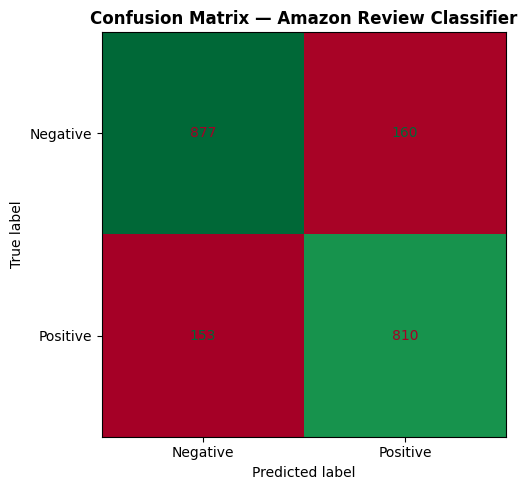

Confusion matrix saved


In [ ]:
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

# Overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Precision, Recall, F1
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Negative", "Positive"])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap="RdYlGn")
ax.set_title("Confusion Matrix — Amazon Review Classifier", fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("Confusion matrix saved")

ACQUIRING FEATURES

In [ ]:
feature_names = vectorizer.get_feature_names_out()
coefficients  = model.coef_[0]

print("Done")
print(f"Total features: {len(feature_names)}")

Done
Total features: 5000


TOP 5 POSITIVE AND TOP 5 NEGATIVE WORDS

In [ ]:
import numpy as np
import pandas as pd

top_positive = pd.DataFrame({
    "word":        feature_names[np.argsort(coefficients)[-20:][::-1]],
    "coefficient": sorted(coefficients)[-20:][::-1],
    "sentiment":   "positive"
})

top_negative = pd.DataFrame({
    "word":        feature_names[np.argsort(coefficients)[:20]],
    "coefficient": sorted(coefficients)[:20],
    "sentiment":   "negative"
})

print("Top 5 positive words:", top_positive["word"].tolist()[:5])
print("Top 5 negative words:", top_negative["word"].tolist()[:5])

Top 5 positive words: ['great', 'love', 'excellent', 'best', 'good']
Top 5 negative words: ['boring', 'waste', 'poor', 'worst', 'disappointed']


COMBINING THEM INTO ONE DATAFRAME

In [ ]:
top_words = pd.concat([top_positive, top_negative])

print(f"Total top words: {len(top_words)}")
print(top_words.head())

Total top words: 40
        word  coefficient sentiment
0      great     7.187467  positive
1       love     5.292963  positive
2  excellent     5.030087  positive
3       best     4.125763  positive
4       good     3.610938  positive


Title done


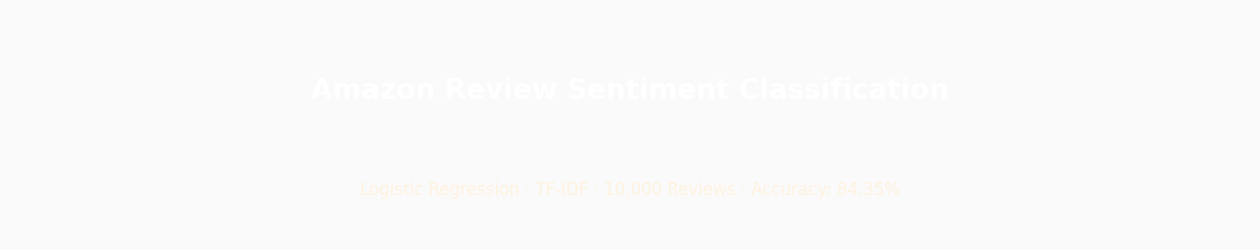

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import confusion_matrix
from matplotlib.patches import Patch

fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor("#FAFAFA")
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.4)

# ── Title banner ──────────────────────────────────────────────
ax_title = fig.add_subplot(gs[0, :])
ax_title.set_facecolor("#FF9900")
ax_title.text(0.5, 0.65, "Amazon Review Sentiment Classification",
              ha="center", va="center", fontsize=20,
              fontweight="bold", color="white",
              transform=ax_title.transAxes)
ax_title.text(0.5, 0.22,
              "Logistic Regression · TF-IDF · 10,000 Reviews · Accuracy: 84.35%",
              ha="center", va="center", fontsize=12,
              color="#FFF3E0", transform=ax_title.transAxes)
ax_title.axis("off")

print("Title done")

KPI CARDS

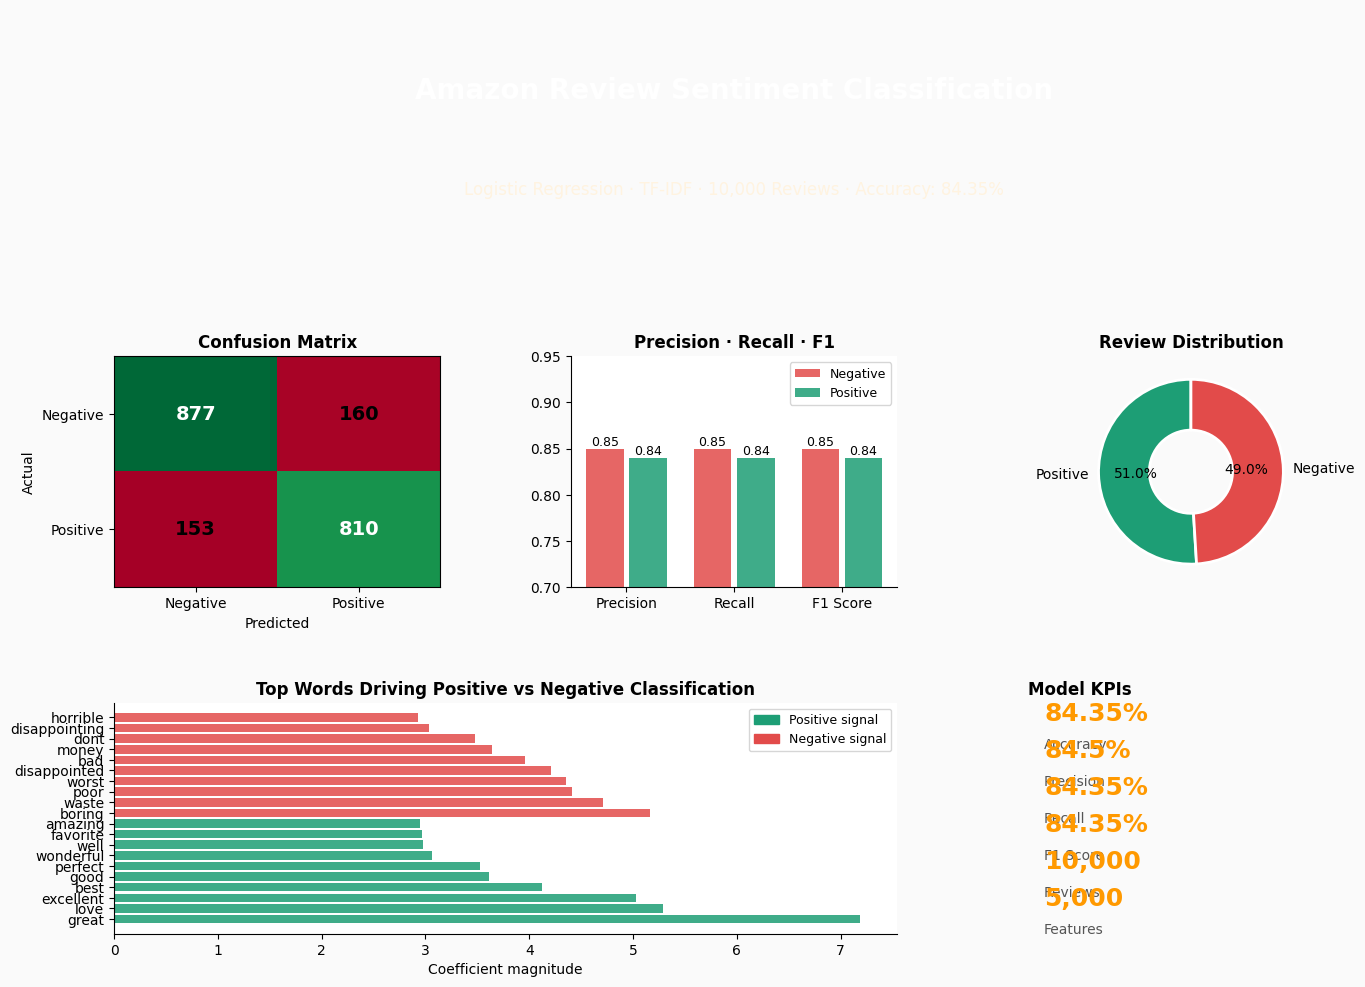

Dashboard complete!


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import confusion_matrix
from matplotlib.patches import Patch

%matplotlib inline

fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor("#FAFAFA")
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.4)

# ── Title banner ──────────────────────────────────────────────
ax_title = fig.add_subplot(gs[0, :])
ax_title.set_facecolor("#FF9900")
ax_title.text(0.5, 0.65, "Amazon Review Sentiment Classification",
              ha="center", va="center", fontsize=20,
              fontweight="bold", color="white",
              transform=ax_title.transAxes)
ax_title.text(0.5, 0.22,
              "Logistic Regression · TF-IDF · 10,000 Reviews · Accuracy: 84.35%",
              ha="center", va="center", fontsize=12,
              color="#FFF3E0", transform=ax_title.transAxes)
ax_title.axis("off")

# ── Chart 1: Confusion matrix ─────────────────────────────────
ax1 = fig.add_subplot(gs[1, 0])
cm  = confusion_matrix(y_test, y_pred)
ax1.imshow(cm, cmap="RdYlGn", aspect="auto")
ax1.set_xticks([0, 1]); ax1.set_yticks([0, 1])
ax1.set_xticklabels(["Negative", "Positive"], fontsize=10)
ax1.set_yticklabels(["Negative", "Positive"], fontsize=10)
ax1.set_xlabel("Predicted", fontsize=10)
ax1.set_ylabel("Actual", fontsize=10)
ax1.set_title("Confusion Matrix", fontweight="bold", fontsize=12)
for i in range(2):
    for j in range(2):
        ax1.text(j, i, str(cm[i, j]), ha="center", va="center",
                 fontsize=14, fontweight="bold",
                 color="white" if cm[i,j] > cm.max()*0.6 else "black")

# ── Chart 2: Precision Recall F1 ─────────────────────────────
ax2             = fig.add_subplot(gs[1, 1])
metrics         = ["Precision", "Recall", "F1 Score"]
negative_scores = [0.85, 0.85, 0.85]
positive_scores = [0.84, 0.84, 0.84]
x = np.arange(len(metrics))
ax2.bar(x - 0.2, negative_scores, 0.35, label="Negative",
        color="#E24B4A", alpha=0.85)
ax2.bar(x + 0.2, positive_scores, 0.35, label="Positive",
        color="#1D9E75", alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(metrics, fontsize=10)
ax2.set_ylim(0.7, 0.95)
ax2.set_title("Precision · Recall · F1", fontweight="bold", fontsize=12)
ax2.legend(fontsize=9)
ax2.spines[["top","right"]].set_visible(False)
for i, (n, p) in enumerate(zip(negative_scores, positive_scores)):
    ax2.text(i - 0.2, n + 0.003, f"{n}", ha="center", fontsize=9)
    ax2.text(i + 0.2, p + 0.003, f"{p}", ha="center", fontsize=9)

# ── Chart 3: Donut ────────────────────────────────────────────
ax3    = fig.add_subplot(gs[1, 2])
counts = df["label"].value_counts()
ax3.pie(counts.values,
        labels=["Positive", "Negative"],
        autopct="%1.1f%%",
        colors=["#1D9E75", "#E24B4A"],
        startangle=90,
        wedgeprops=dict(width=0.55, edgecolor="white", linewidth=2))
ax3.set_title("Review Distribution", fontweight="bold", fontsize=12)

# ── Chart 4: Top words ────────────────────────────────────────
ax4       = fig.add_subplot(gs[2, :2])
top10_pos = top_positive.head(10)
top10_neg = top_negative.head(10)
combined  = pd.concat([top10_pos, top10_neg])
colors    = ["#1D9E75" if s == "positive" else "#E24B4A"
             for s in combined["sentiment"]]
ax4.barh(combined["word"], abs(combined["coefficient"]),
         color=colors, alpha=0.85)
ax4.set_title("Top Words Driving Positive vs Negative Classification",
              fontweight="bold", fontsize=12)
ax4.set_xlabel("Coefficient magnitude", fontsize=10)
ax4.spines[["top","right"]].set_visible(False)
ax4.legend(handles=[
    Patch(color="#1D9E75", label="Positive signal"),
    Patch(color="#E24B4A", label="Negative signal")
], fontsize=9)

# ── Chart 5: KPI cards ────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 2])
ax5.axis("off")
kpis = [
    ("Accuracy",  "84.35%"),
    ("Precision", "84.5%"),
    ("Recall",    "84.35%"),
    ("F1 Score",  "84.35%"),
    ("Reviews",   "10,000"),
    ("Features",  "5,000"),
]
for i, (label, val) in enumerate(kpis):
    ax5.text(0.05, 0.92 - i*0.16, val,
             transform=ax5.transAxes,
             fontsize=18, fontweight="bold", color="#FF9900")
    ax5.text(0.05, 0.80 - i*0.16, label,
             transform=ax5.transAxes,
             fontsize=10, color="#555")
ax5.set_title("Model KPIs", fontweight="bold", fontsize=12, loc="left")

# ── Save and show ─────────────────────────────────────────────
plt.savefig("amazon_sentiment_dashboard.png", dpi=180,
            bbox_inches="tight", facecolor="#FAFAFA")
plt.show()
print("Dashboard complete!")

In [ ]:
# ── Export 1: Full predictions ────────────────────────────────
results_df = pd.DataFrame({
    "text_clean":          X_test.values,
    "actual_label":        y_test.values,
    "predicted_label":     y_pred,
    "correct":             (y_test.values == y_pred).astype(int),
    "actual_sentiment":    ["Positive" if l == 1 else "Negative"
                             for l in y_test.values],
    "predicted_sentiment": ["Positive" if l == 1 else "Negative"
                             for l in y_pred],
})
results_df.to_csv("predictions.csv", index=False)
print(f"Exported {len(results_df)} rows → predictions.csv")

# ── Export 2: Top words ───────────────────────────────────────
top_words.to_csv("top_words.csv", index=False)
print("Exported → top_words.csv")

# ── Export 3: Model metrics ───────────────────────────────────
metrics_df = pd.DataFrame({
    "metric":  ["Accuracy", "Precision (Neg)", "Precision (Pos)",
                "Recall (Neg)", "Recall (Pos)", "F1 (Neg)", "F1 (Pos)"],
    "value":   [84.35, 85, 84, 85, 84, 85, 84],
    "class":   ["Overall", "Negative", "Positive",
                "Negative", "Positive", "Negative", "Positive"],
})
metrics_df.to_csv("model_metrics.csv", index=False)
print("Exported → model_metrics.csv")

# ── Export 4: Confusion matrix ────────────────────────────────
cm_df = pd.DataFrame({
    "actual":    ["Negative", "Negative", "Positive", "Positive"],
    "predicted": ["Negative", "Positive", "Negative", "Positive"],
    "count":     [cm[0,0], cm[0,1], cm[1,0], cm[1,1]],
    "type":      ["True Negative", "False Positive",
                  "False Negative", "True Positive"],
})
cm_df.to_csv("confusion_matrix_data.csv", index=False)
print("Exported → confusion_matrix_data.csv")

# ── Download all ──────────────────────────────────────────────
from google.colab import files
for f in ["predictions.csv", "top_words.csv",
          "model_metrics.csv", "confusion_matrix_data.csv",
          "amazon_sentiment_dashboard.png"]:
    files.download(f)

print("\nAll files downloaded! Ready for Power BI.")

Exported 2000 rows → predictions.csv
Exported → top_words.csv
Exported → model_metrics.csv
Exported → confusion_matrix_data.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


All files downloaded! Ready for Power BI.
